![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

### Group Members: Elvis Casco, Xianrui Cao, Román Feria

# TEXT MINING FINAL PROJECT

**Abstract**

Online reviews play a crucial role in shaping consumer decisions in digital marketplaces such as Airbnb. While numerical ratings provide a simple summary of guest satisfaction, written reviews contain richer information about the aspects of a stay that guests value most or find problematic. This project applies text mining and natural language processing techniques to analyze Airbnb reviews and identify linguistic patterns associated with positive and negative guest experiences.

Using review data obtained from the Inside Airbnb dataset, we first perform exploratory data analysis to understand the structure of the dataset and the general characteristics of the reviews. The text is then preprocessed through standard natural language processing steps including lowercasing, punctuation removal, and stopword filtering in order to construct a clean textual corpus suitable for analysis.

We then apply term-frequency based methods, such as TF-IDF, to identify the most informative words that characterize different types of reviews. In addition, topic modeling techniques are used to uncover common themes discussed by guests, such as location, cleanliness, and communication with hosts. Finally, a supervised classification model is trained to evaluate whether the textual content of reviews can be used to predict whether a guest experience was positive or negative.

Through this analysis, the project demonstrates how text mining techniques can extract meaningful insights from unstructured review data and provide a systematic understanding of the factors that shape guest satisfaction in the Airbnb platform.

# 1. Import libraries and retrieve the data

In [2]:
# Basic libraries for DS
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from pprint import pprint

from time import time

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score

# Libraries for preprocessing
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.corpus import stopwords
%pip install spacy
import spacy
from matplotlib import pyplot as plt
from tqdm import tqdm

# Libraries for TF-IDF
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer, TfidfVectorizer

# Libraries for LDA
import scipy
%pip install gensim
from gensim import corpora, models
from gensim.matutils import Sparse2Corpus
from scipy.sparse import csr_matrix
import nltk
from nltk.corpus import stopwords
from gensim.models import CoherenceModel
%pip install wordcloud
from wordcloud import WordCloud

# Libraries for Supervised Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as p
from textblob import TextBlob
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# RETRIEVE THE DATA

# Data with only the translated reviews into English using Google Translator
filename_reviews_translated ='https://media.githubusercontent.com/media/ElvisCasco/Text_Mining_Project/refs/heads/main/reviews_translated.csv'
reviews_translated = pd.read_csv(filename_reviews_translated, sep=',', encoding='utf-8')

# Remove nulls and <br> from the text
reviews_translated_clean = reviews_translated.dropna(subset=['Reviews_Translation'])

reviews_translated_clean['Reviews_Translation'] = reviews_translated_clean['Reviews_Translation'].str.replace('<br>', '', regex=False)
reviews_translated_clean['Reviews_Translation'] = reviews_translated_clean['Reviews_Translation'].str.replace('br', '', regex=False)
reviews_translated_clean.info()
reviews_translated_clean.head()

<class 'pandas.DataFrame'>
Index: 1015329 entries, 0 to 1019268
Data columns (total 7 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   listing_id           1015329 non-null  int64
 1   id                   1015329 non-null  int64
 2   date                 1015329 non-null  str  
 3   reviewer_id          1015329 non-null  int64
 4   reviewer_name        1015325 non-null  str  
 5   comments             1015298 non-null  str  
 6   Reviews_Translation  1015329 non-null  str  
dtypes: int64(3), str(4)
memory usage: 62.0 MB


,listing_id,id,date,reviewer_id,reviewer_name,comments,Reviews_Translation
0,703984,415003002495917725,2021-07-26,324403082,Gabriela,"Excelente lugar y buena ubicación, repetiría e...","Excellent place and good location, I would rep..."
1,703984,422225979748637708,2021-08-05,208472604,Abdoulaye,Very good host and always ready to help,Very good host and always ready to help
2,703984,428711187547685597,2021-08-14,75793287,Nikos,Excellent place to stay and great location. Re...,Excellent place to stay and great location. Re...
3,703984,435298891748897953,2021-08-23,207073569,Berta,"Easy and quick communication with the host, gr...","Easy and quick communication with the host, gr..."
4,703984,438894164765136324,2021-08-28,391402125,Ahmad,Beautiful apartment in a very great neighbourh...,Beautiful apartment in a very great neighbourh...


In [4]:
# Data with the preprocessed comments (using the preprocessment defined in the project)
preprocessed_comments = pd.read_csv('https://media.githubusercontent.com/media/ElvisCasco/Text_Mining_Project/refs/heads/main/preprocessed_comments.csv', sep=',', encoding='utf-8')
preprocessed_comments_clean = preprocessed_comments.dropna(subset=['Reviews_Translation'])

# We remove <br> as a term
preprocessed_comments_clean['Reviews_Translation'] = preprocessed_comments_clean['Reviews_Translation'].str.replace('<br>', '', regex=False)
preprocessed_comments_clean['Reviews_Translation'] = preprocessed_comments_clean['Reviews_Translation'].str.replace('br', '', regex=False)
preprocessed_comments_clean.info()
preprocessed_comments_clean.head()

<class 'pandas.DataFrame'>
Index: 100172 entries, 0 to 100414
Data columns (total 1 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Reviews_Translation  100172 non-null  str  
dtypes: str(1)
memory usage: 1.5 MB


,Reviews_Translation
0,excellent place good location repeat place hes...
1,good host ready help
2,excellent place stay great location recommend
3,easy quick communication host great location s...
4,beautiful apartment great neighbourhood mainta...


# 2. Exploratory Data Analysis

Before applying text mining techniques, we perform an exploratory analysis of the dataset in order to better understand its structure and general characteristics. Exploratory Data Analysis (EDA) helps identify potential issues in the data, such as missing values, extremely short or long reviews, and irregularities in the textual content.

In this stage, we focus on examining the basic properties of the review corpus. This includes inspecting the number of observations, exploring examples of the review text, and analyzing the distribution of review lengths. Studying the length of reviews can provide useful insights into how users typically describe their experiences on the platform and whether the dataset contains outliers that may affect the analysis.

Additionally, we analyze the most frequent words appearing in the corpus. This provides an initial overview of the dominant vocabulary used by guests when describing their stays. Such insights can highlight commonly discussed aspects of Airbnb experiences, such as location, cleanliness, communication with the host, or the overall quality of the accommodation.

The results of this exploratory analysis help guide the preprocessing and modeling steps that follow, ensuring that the text mining techniques are applied to a well-understood and properly prepared dataset.

## 2.1 Frequency of words

We compute the frequency of the words and we show the distribution that it follows from the first 20 words.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Vectorizer to count the number of words
vectorizer = CountVectorizer(
    stop_words='english'
)

X_counts = vectorizer.fit_transform(reviews_translated_clean['Reviews_Translation'])

# Sum frequencies
word_counts = np.asarray(X_counts.sum(axis=0)).ravel()

# We obtain the words
words = vectorizer.get_feature_names_out()

# We create a dataframe word-count
df_words = pd.DataFrame({
    'word': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)

df_words.head(20)

,word,count
10919,apartment,517852
56595,great,417583
74582,location,359166
117830,stay,338840
94795,place,252091
26801,clean,240274
55952,good,229138
16441,barcelona,214255
85398,nice,198897
61062,host,175621


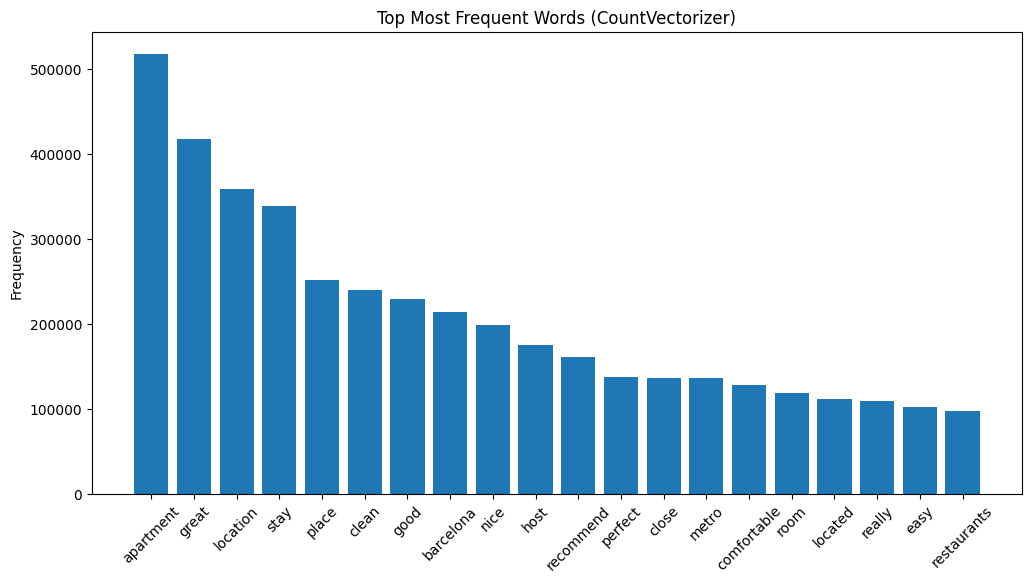

In [6]:
# We plot the first 20 words that are more frequent
top_n = 20
top_words = df_words.head(top_n)

plt.figure(figsize=(12,6))
plt.bar(top_words['word'], top_words['count'])

plt.xticks(rotation=45)
plt.title("Top Most Frequent Words (CountVectorizer)")
plt.ylabel("Frequency")

plt.show()

## 2.2 Reviews Length

We want to plot the distribution of the average length of the reviews

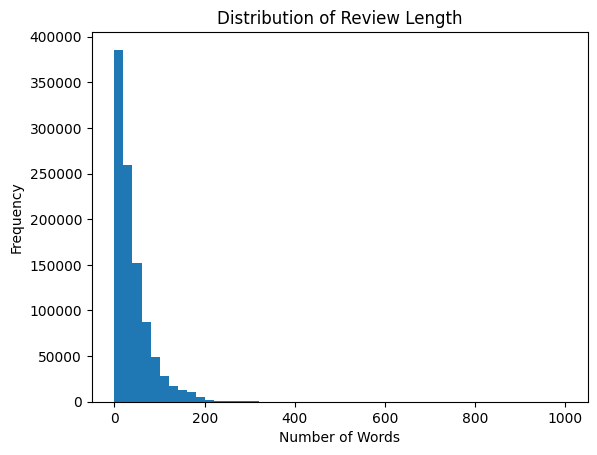

In [7]:
review_length = reviews_translated_clean['Reviews_Translation'].apply(
    lambda x: len(x.split())
)

plt.hist(review_length, bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## 2.3 Number of unique words

In [8]:
print("Vocabulary size:", len(words))

Vocabulary size: 190864


## 2.4 Frequency common vs uncommon words

We want to compare the frequency between common and uncommon words and check how these distribution behaves. As we can see, the distribution of word frequencies is highly skewed, with most terms appearing only a few times and a small number of words occurring very frequently. This long-tail distribution is typical of natural language data and motivates the use of minimum and maximum document frequency thresholds.

In [9]:
print(df_words.describe())
# We check differents counts to determine which min_df and max_df should fit better
df_words[df_words['count'] < 200]

               count
count  190864.000000
mean      105.834007
std      2778.128732
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max    517852.000000


,word,count
111228,searching,199
55942,gonzalo,199
18431,benissimo,199
126273,translator,199
37956,disruptive,199
...,...,...
190857,𝒑𝒂𝒓𝒂,1
190856,𝒍𝒐,1
190855,𝒍𝒂,1
190854,𝒊𝒅𝒆𝒂𝒍,1


# 3. Text Preprocessing

Before applying text mining techniques, the raw textual data must be cleaned and standardized. Raw reviews often contain punctuation, capital letters, and common words that do not contribute meaningful information for the analysis. Therefore, a series of preprocessing steps are applied to transform the raw text into a structured textual corpus suitable for analysis.

The preprocessing pipeline typically includes converting all text to lowercase, removing punctuation and non-alphabetic characters, and filtering out common stopwords such as “the”, “and”, or “is”. These steps help reduce noise in the dataset and focus the analysis on informative words that better capture the content of the reviews.

After preprocessing, the cleaned text is used to construct a document-term representation of the corpus, which allows us to apply techniques such as TF-IDF weighting and supervised classification models in the later stages of the analysis.

WE NEED TO REMARK that to avoid running this preprocessment multiple times, we ran it once and saved the preprocessed comments in a github repository. You can see the result in the first section 'Import libraries and retrieve the data'. We are showing the code that we used to preprocess it, but it's commented due to this reason.

In [10]:
# Function to download NLTK resources
def download_nltk_resources():
    required_resources = ['wordnet', 'stopwords', 'punkt']
    for resource in required_resources:
        try:
            nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
        except LookupError:
            nltk.download(resource)

download_nltk_resources()

# Load spaCy model; if missing, install it in the current Jupyter kernel environment.
try:
    sp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download

    print("Installing spaCy model 'en_core_web_sm' for this environment...")
    spacy_download('en_core_web_sm')
    sp = spacy.load('en_core_web_sm')

# Enable tqdm for pandas
tqdm.pandas()

# Initialize stemmers and lemmatizer
porter = SnowballStemmer("english")
lmtzr = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/romanferia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
#General functions for the preprocessing
"""
This module provides helper functions for text preprocessing.
Each function applies punctuation removal and stopword removal, and then one of three options:
    0: Lowercasing only.
    1: Lowercasing plus stemming.
    2: Lemmatizing (using spaCy; original casing is preserved).

The functions return a string of tokens separated by spaces.
"""

def preprocess_lower(text):
    """
    Preprocess text by:
       - Converting to lowercase.
       - Removing punctuation.
       - Tokenizing.
       - Removing stopwords.

    Returns:
        str: A string of filtered tokens separated by spaces.
    """
    text_lower = text.lower()
    text_no_punct = re.sub(r'[^\w\s]', '', text_lower)
    tokens = word_tokenize(text_no_punct)
    filtered_tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(filtered_tokens)

def preprocess_stem(text):
    """
    Preprocess text by performing all steps in preprocess_lower() and then applying stemming.

    Returns:
        str: A string of stemmed tokens separated by spaces.
    """
    tokens = preprocess_lower(text).split()
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

def preprocess_lemma(text):
    """
    Preprocess text by:
       - Removing punctuation and stopwords using spaCy's token attributes.
       - Lemmatizing the text.
       - (Note: This function does NOT lowercase the text.)

    Returns:
        str: A string of lemmatized tokens separated by spaces.
    """
    doc = sp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.lemma_.strip() != '']
    return " ".join(lemmatized_tokens)

def tokenize(text, mode=0):
    """
    General tokenize function. Always applies punctuation and stopword removal and then:

      mode = 0: Applies lowercasing.
      mode = 1: Applies lowercasing and stemming.
      mode = 2: Applies lemmatization (without lowercasing the original text).

    Args:
        text (str): The input text to be processed.
        mode (int): Processing mode (0 for lowercasing; 1 for stemming; 2 for lemmatizing).

    Returns:
        str: A string of processed tokens separated by spaces.

    Raises:
        ValueError: If an invalid mode is provided.
    """
    if mode == 0:
        return preprocess_lower(text)
    elif mode == 1:
        return preprocess_stem(text)
    elif mode == 2:
        return preprocess_lemma(text)
    else:
        raise ValueError("Invalid mode. Please use 0 for lowercasing, 1 for stemming, or 2 for lemmatizing.")

In [12]:
#As previously explained, we comment this part to run the code faster. Results seen in section 1 of this notebook.
"""#1. Remove punctuation and digits and remove stopwords, and lemmatizing
mod = 2

# Pre-process the text column with progress tracking
try:
    preprocessed_comments = comments.astype(str).progress_apply(lambda row: tokenize(row, mod))
    print("Done processing text.")
except Exception as e:
    print(f"Error processing text column: {e}")
    raise RuntimeError(f"Error processing text column: {e}") from e

print(preprocessed_comments.head())"""

'#1. Remove punctuation and digits and remove stopwords, and lemmatizing\nmod = 2\n\n# Pre-process the text column with progress tracking\ntry:\n    preprocessed_comments = comments.astype(str).progress_apply(lambda row: tokenize(row, mod))\n    print("Done processing text.")\nexcept Exception as e:\n    print(f"Error processing text column: {e}")\n    raise RuntimeError(f"Error processing text column: {e}") from e\n\nprint(preprocessed_comments.head())'

# 4. TF_IDF Implementation:
Term Frequency–Inverse Document Frequency (TF-IDF) will be used to identify words that are most important for distinguishing positive and negative reviews.
Separate TF-IDF scores will be analyzed for positive and negative reviews.
This helps identify the most characteristic words in each group.


In [13]:
text_for_tfidf = preprocessed_comments_clean['Reviews_Translation']
text_for_tfidf = text_for_tfidf.fillna('').astype(str)
text_for_tfidf = text_for_tfidf[text_for_tfidf.str.strip().ne('')]

corpus_data = pd.DataFrame({'text_preproc': text_for_tfidf.reset_index(drop=True)})

# Fit TF-IDF 
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    min_df=200,
    max_df=0.8,
    lowercase=False
)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_data['text_preproc'])

terms = tfidf_vectorizer.get_feature_names_out()
# Use total TF-IDF weight across all reviews so the graph is not shown as an average-like percentage.
idf_values = tfidf_vectorizer.idf_

df_tfidf_terms = pd.DataFrame({
    'term': terms,
    'tfidf': idf_values
})

df_tfidf_terms = df_tfidf_terms.sort_values(by='tfidf', ascending=False).reset_index(drop=True)
df_tfidf_terms['id'] = df_tfidf_terms.index + 1
df_terms = df_tfidf_terms.copy()

print('TF-IDF scores shown below are total weights across all reviews.')
print(df_tfidf_terms.head(10))

KeyboardInterrupt: 

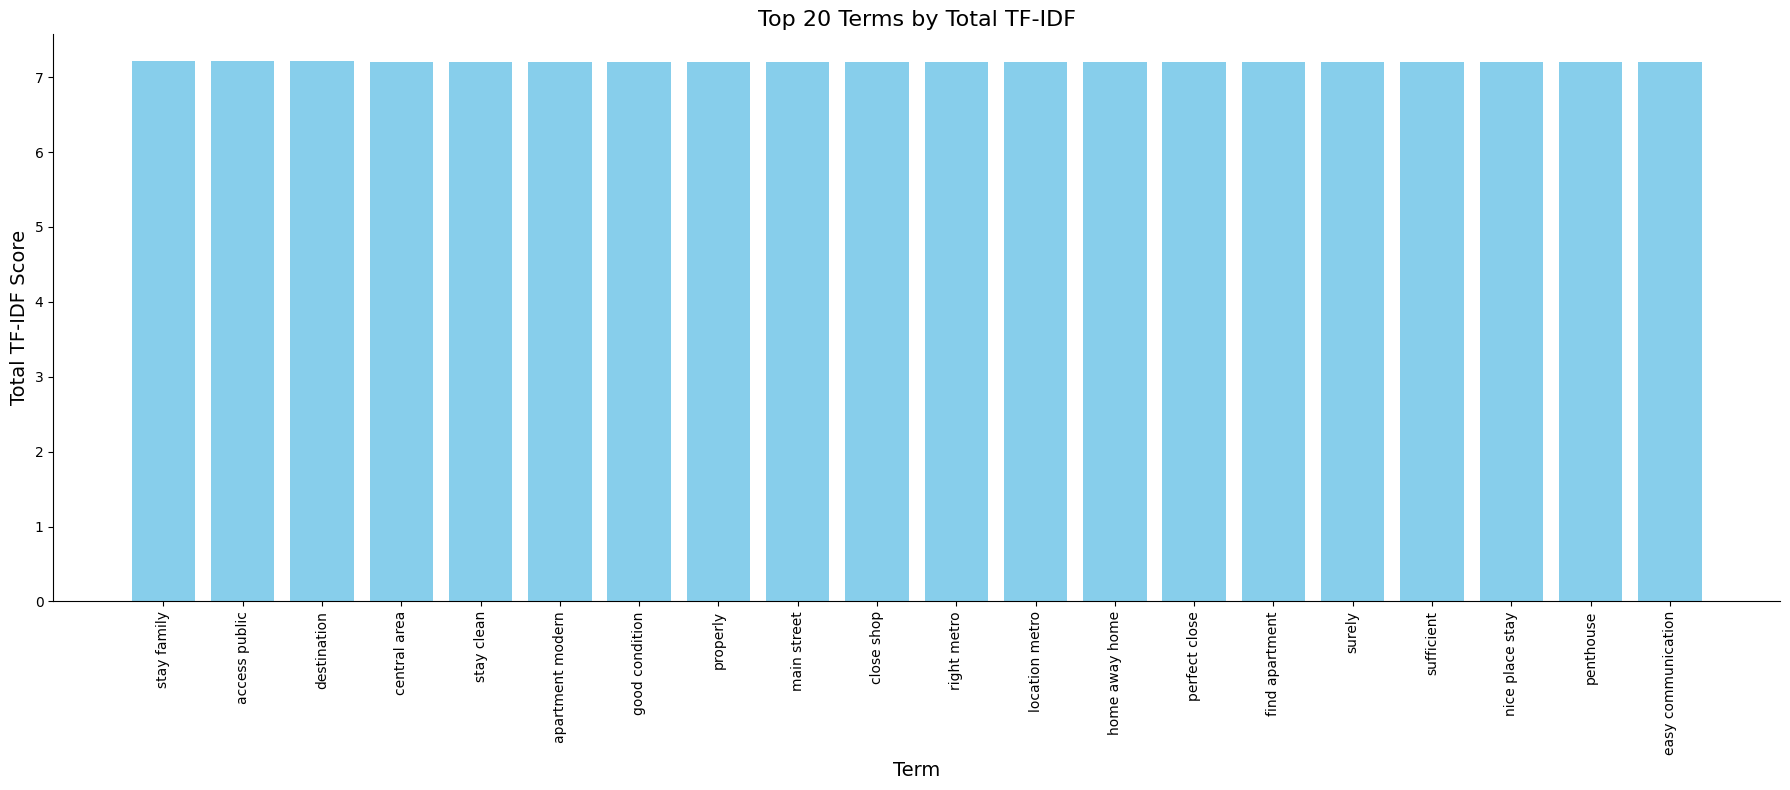

In [ ]:
top_n = min(20, df_tfidf_terms.shape[0])
plot_data = df_tfidf_terms.head(top_n).copy()

plt.figure(figsize=(18, 8))
plt.bar(plot_data['term'], plot_data['tfidf'], color='skyblue')

plt.xlabel('Term', fontsize=14)
plt.ylabel('Total TF-IDF Score', fontsize=14)
plt.title(f'Top {top_n} Terms by Total TF-IDF', fontsize=16)
plt.xticks(rotation=90, fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 5. Topic Modeling (LDA)
Latent Dirichlet Allocation (LDA) will be used to identify latent topics in the reviews.
Each topic will be interpreted based on its most important words.
This helps uncover common themes such as cleanliness, location, or communication.

## 5.1 Compute Optimal Number of Topics (k)

We want to determine which values for the parameters min_df and max_df are optimal in order to compute highest coherence score. Therefore, we try with differents values and different number of topics. What we saw is that the coherence score does not vary that much from one set of values to other, so we pick a sensible number of topics which make the interpretations of the topics easier to understand according to human knowledge.

Evaluating optimal number of topics...
(This will take some time as it trains multiple LDA models. Passes are reduced to 2 for speed.)
Training model with 3 topics...
  -> Coherence Value: 0.6151
Training model with 4 topics...
  -> Coherence Value: 0.6125
Training model with 5 topics...
  -> Coherence Value: 0.6044
Training model with 6 topics...
  -> Coherence Value: 0.6064
Training model with 7 topics...
  -> Coherence Value: 0.6083
Training model with 8 topics...
  -> Coherence Value: 0.6188
Training model with 9 topics...
  -> Coherence Value: 0.6125
Training model with 10 topics...
  -> Coherence Value: 0.6067
Training model with 11 topics...
  -> Coherence Value: 0.6108
Training model with 12 topics...
  -> Coherence Value: 0.5944
Training model with 13 topics...
  -> Coherence Value: 0.5856
Training model with 14 topics...
  -> Coherence Value: 0.5675
Training model with 15 topics...
  -> Coherence Value: 0.5978


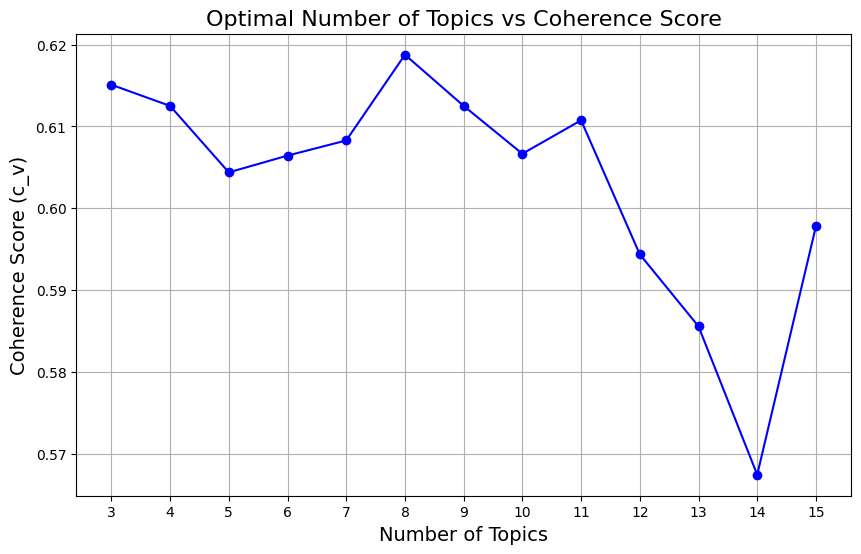

In [ ]:
preprocessed_text = preprocessed_comments_clean['Reviews_Translation']

custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update(["apartment","stay","great","nice","good",
    "place","location","barcelona", "de", "et", "appartement"])

count_vectorizer = CountVectorizer(stop_words=list(custom_stopwords), min_df=5, max_df=0.7)
count_data = count_vectorizer.fit_transform(preprocessed_text)

dtm_sparse = csr_matrix(count_data)
corpus_gensim = Sparse2Corpus(dtm_sparse, documents_columns=False)

vocabulary_gensim = {val: key for key, val in count_vectorizer.vocabulary_.items()}
dictionary = corpora.Dictionary()
dictionary.id2token = vocabulary_gensim
dictionary.token2id = count_vectorizer.vocabulary_

# Define range to evaluate
start_topics = 3
limit_topics = 16  # 16 is exclusive, so it goes up to 15
step = 1

coherence_values = []
model_list = []

print("Evaluating optimal number of topics...")
print("(This will take some time as it trains multiple LDA models. Passes are reduced to 2 for speed.)")

workers = max(1, os.cpu_count() - 1)

# We need the tokenized texts for the 'c_v' coherence metric
texts = [str(doc).split() for doc in preprocessed_text]

for num_topics in range(start_topics, limit_topics, step):
    print(f"Training model with {num_topics} topics...")
    # Build LDA model (fewer passes to speed up evaluation)
    model = models.LdaMulticore(
        corpus=corpus_gensim,
        num_topics=num_topics,
        id2word=dictionary,
        passes=2,
        workers=workers,
        random_state=42
    )
    model_list.append(model)

    # Compute Coherence Score
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    score = coherencemodel.get_coherence()
    coherence_values.append(score)
    print(f"  -> Coherence Value: {score:.4f}")

# Plot the results
x = range(start_topics, limit_topics, step)
plt.figure(figsize=(10, 6))
plt.plot(x, coherence_values, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Topics", fontsize=14)
plt.ylabel("Coherence Score (c_v)", fontsize=14)
plt.title("Optimal Number of Topics vs Coherence Score", fontsize=16)
plt.xticks(x)
plt.grid(True)
plt.show()

## 5.2 Run LDA

According to our analysis, 4 is the optimal number of topics in terms of trade-off between coherence score and human interpretability, so we run LDA with this value. We also implement it in a way that runs it faster in terms of computational cost. 

In [ ]:
#Run LDA
num_topics = 4

print(f"Running LDA with {num_topics} topics...")
print("(Optimized for speed using LdaMulticore...)")

# Get available CPU cores (leave 1 free for the system)
workers = max(1, os.cpu_count() - 1)

# Build LDA model optimized for speed
lda_model = models.LdaMulticore(
    corpus=corpus_gensim,
    id2word=dictionary,
    num_topics=num_topics,
    passes=10,          # Reduced from 20. 5-10 is usually enough for a large corpus
    chunksize=10000,    # Process more documents in memory per batch
    workers=workers,    # Use multiple CPU cores
    random_state=42
)

print("\n LDA model trained!")

# Display topics
print("\n=== LDA Topics (Top 10 words each) ===")
topics = lda_model.print_topics(num_words=10)
for idx, topic in topics:
    print(f"\nTopic {idx}: {topic}")

Running LDA with 4 topics...
(Optimized for speed using LdaMulticore...)

 LDA model trained!

=== LDA Topics (Top 10 words each) ===

Topic 0: 0.009*"time" + 0.009*"comfortable" + 0.008*"check" + 0.008*"need" + 0.007*"day" + 0.007*"clean" + 0.006*"bed" + 0.006*"helpful" + 0.006*"space" + 0.006*"kitchen"

Topic 1: 0.028*"recommend" + 0.026*"host" + 0.019*"clean" + 0.018*"perfect" + 0.012*"highly" + 0.011*"close" + 0.011*"need" + 0.010*"definitely" + 0.010*"easy" + 0.010*"thank"

Topic 2: 0.023*"metro" + 0.018*"walk" + 0.016*"minute" + 0.015*"close" + 0.012*"area" + 0.012*"clean" + 0.011*"restaurant" + 0.010*"locate" + 0.010*"station" + 0.009*"away"

Topic 3: 0.017*"room" + 0.014*"clean" + 0.014*"host" + 0.010*"excellent" + 0.008*"bed" + 0.008*"thank" + 0.008*"bathroom" + 0.007*"locate" + 0.007*"kitchen" + 0.007*"small"


### Classification of the topics
##### Topic 0 → Comfort & Amenities
##### Topic 1 → Host Interaction
##### Topic 2 → Location & Accessibility
##### Topic 3 → Room Quality

## 5.3 WordClouds

We plot the wordclouds for each of the topics, so we can see what words compose each topics and their respective weights.

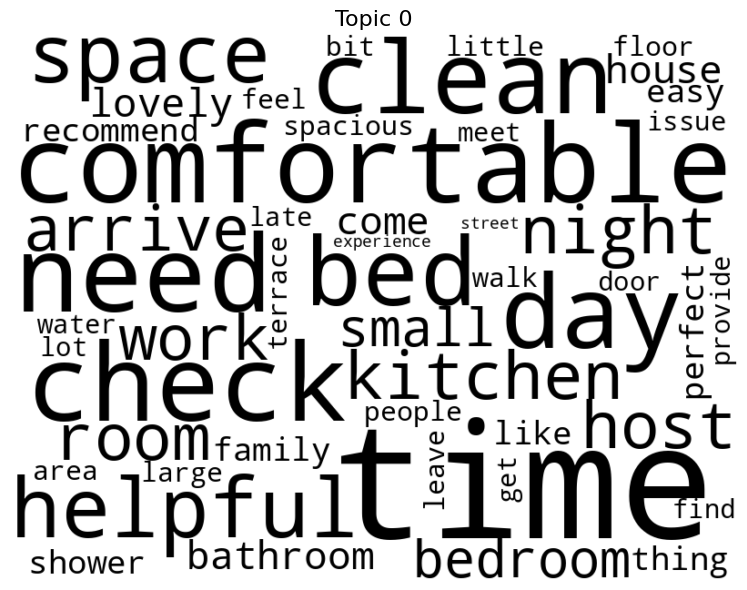

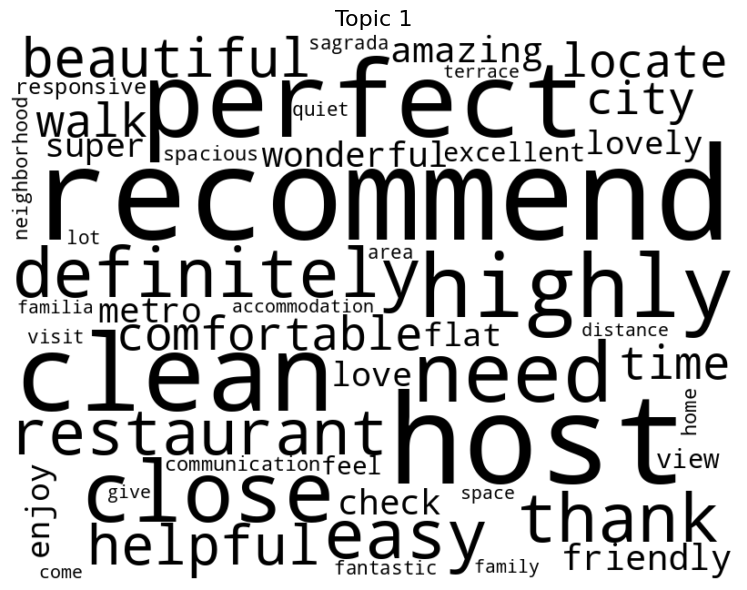

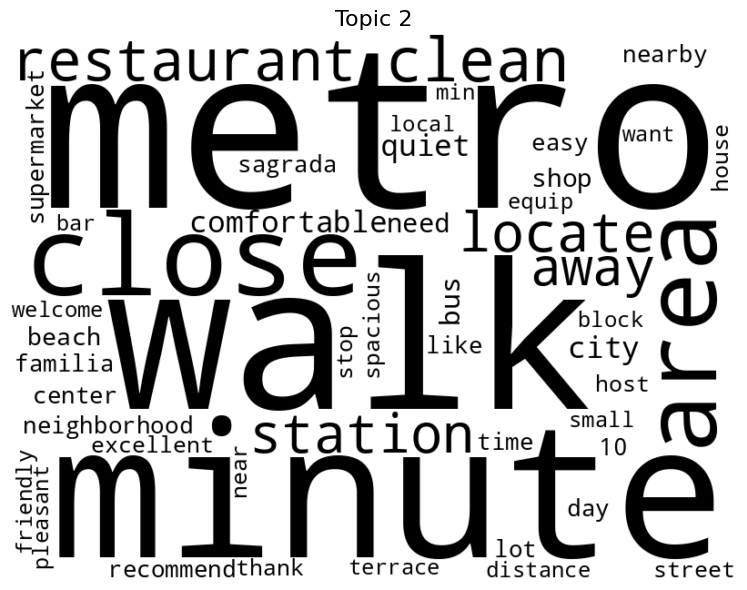

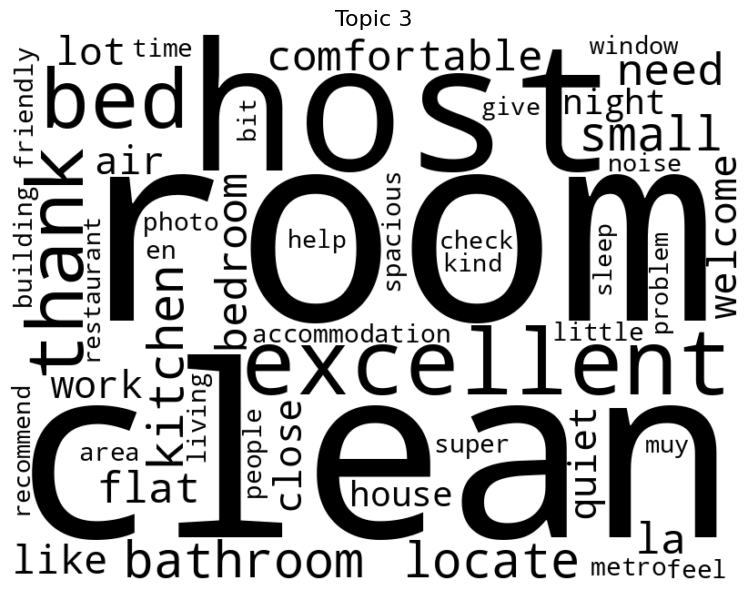

In [ ]:
# Topic Wordclouds
topics_full = lda_model.show_topics(num_topics=-1, num_words=50, formatted=False)

for topic_num, topic_words in topics_full:
    word_freq = dict(topic_words)
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        color_func=lambda *args, **kwargs: "black",
        min_font_size=10
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f'Topic {topic_num}', fontsize=16)
    plt.tight_layout()
    plt.show()

## 5.4 Verification Valid Topic Distributions

In [ ]:
# Verify Topic Distributions, meaning that topic shares sum to 1

# Get topic distributions for each document
# lda_model.get_document_topics returns a list of lists, where each inner list
# contains (topic_id, probability) pairs for a document.
document_topics = lda_model.get_document_topics(corpus_gensim, minimum_probability=0.0)

# Create a list of dictionaries, one for each document's topic probabilities
# The dictionary keys will be 'topic_0', 'topic_1', etc.
topic_distributions = []
for doc_topics in document_topics:
    doc_topic_dict = {f'topic_{topic_id}': prob for topic_id, prob in doc_topics}
    topic_distributions.append(doc_topic_dict)

# Convert the list of dictionaries to a DataFrame
df_topic_distributions = pd.DataFrame(topic_distributions).fillna(0)

# Concatenate with the original corpus_data. Reset index to ensure alignment.
corpus_data = pd.concat([corpus_data.reset_index(drop=True), df_topic_distributions], axis=1)

# Now, verify topic shares sum to 1
corpus_data['topic_sum'] = corpus_data[[f'topic_{i}' for i in range(num_topics)]].sum(axis=1)
corpus_data['sum_is_1'] = np.isclose(corpus_data['topic_sum'], 1.0)

summary = corpus_data['sum_is_1'].value_counts()
print("=== Topic Distribution Validation ===")
print(summary)
print(f"\n All distributions valid: {summary.get(True, 0) == len(corpus_data)}")

=== Topic Distribution Validation ===
sum_is_1
True    100172
Name: count, dtype: int64

 All distributions valid: True


# 6. Supervised Classification

To further analyze the information contained in Airbnb reviews, we implement a supervised machine learning approach to predict whether a review reflects a positive or negative guest experience, and therefore determine which words or features lead to positive or negative experiences. Finally, we will compute the importance of each topic using these coefficients (in the case of logistic regression) or the importance grade (in the case of random forest). We will analyze each model separately and then combine them using a normalization of the values.

Since the dataset does not include explicit sentiment labels, we first generate a binary target variable using sentiment analysis. Each review is assigned a polarity score, which is then used to classify the review as either positive or negative.

Next, the textual reviews are transformed into numerical features using TF–IDF vectorization, which represents each review as a weighted combination of words based on their importance in the corpus. The dataset is then split into training and testing sets in order to evaluate the model's ability to generalize to unseen data.

Finally, a classification model is trained using the TF–IDF features to predict the sentiment label of each review. The model’s performance is evaluated using standard metrics such as accuracy and confusion matrices, and the most informative words identified by the model are analyzed to better understand which linguistic features are associated with positive and negative Airbnb experiences.

Here are the steps we followed:
1. Label Generation
2. Train Logistic Regression and Random Forest classifiers
3. Extract coefficients / feature importances
4. Combine importances
5. Compute weighted topic importance using LDA probabilities


## 6.1 Label Generation via Sentiment Analysis

Since the dataset does not contain labels, we generate binary sentiment labels using TextBlob.
Positive sentiment -> 1
Negative sentiment -> 0

Unfortunately, we can see there is an imbalance between positive and negative reviews. We will deal with it in the implementation of the models. 


Reviews_Translation
1    86222
0    13950
Name: count, dtype: int64


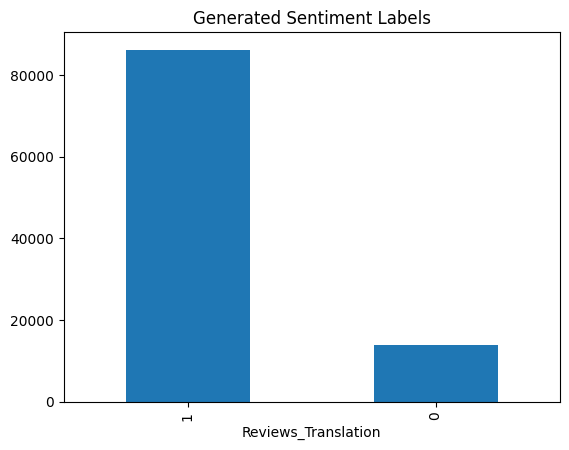

In [ ]:
# Generate polarity
sentiment_scores = preprocessed_text.astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# Create labels
labels = sentiment_scores.apply(lambda x: 1 if x > 0 else 0)

print(labels.value_counts())

# Plot the distribution
import matplotlib.pyplot as plt

labels.value_counts().plot(kind='bar')
plt.title("Generated Sentiment Labels")
plt.show()


## 6.2 Logisitic Regression model

In [ ]:
# X_tfidf is the document-term matrix that we got from section 4
X = X_tfidf
y = labels  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# We train the model
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Metrics
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

roc_auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC Logistic:", roc_auc_log)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.76      0.97      0.85      2740
           1       0.99      0.95      0.97     17295

    accuracy                           0.95     20035
   macro avg       0.88      0.96      0.91     20035
weighted avg       0.96      0.95      0.96     20035

Confusion Matrix
[[ 2645    95]
 [  813 16482]]
ROC-AUC Logistic: 0.9915734369032018


In [ ]:
# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Logistic coefficients
log_coefs = log_model.coef_[0]

# Create dataframe
log_df = pd.DataFrame({
    "term": feature_names,
    "coefficient": log_coefs
})

# Most positive terms
top_positive = log_df.sort_values("coefficient", ascending=False).head(20)

# Most negative terms
top_negative = log_df.sort_values("coefficient", ascending=True).head(20)

print("Top positive terms")
print(top_positive)

print("\nTop negative terms")
print(top_negative)

Top positive terms
             term  coefficient
821         great    17.175785
796          good    15.641298
1203         nice    13.694419
492   comfortable    12.857960
443         clean    12.257470
767      friendly    11.022341
1326     pleasant    10.872407
222       amazing    10.384703
1811    wonderful    10.379313
1279      perfect    10.229777
683     excellent    10.105779
631          easy    10.038667
1102       lovely     9.327172
1797      welcome     9.265843
1096         love     8.963438
716     fantastic     8.328848
352     beautiful     7.475959
330     available     7.463211
1616        super     7.402375
649         enjoy     7.308998

Top negative terms
                term  coefficient
337              bad    -6.729273
600            dirty    -5.592101
344             base    -4.598177
1733   unfortunately    -4.293676
594        difficult    -4.150888
1730   uncomfortable    -3.915440
488             cold    -3.595296
693        expensive    -3.129188
1514

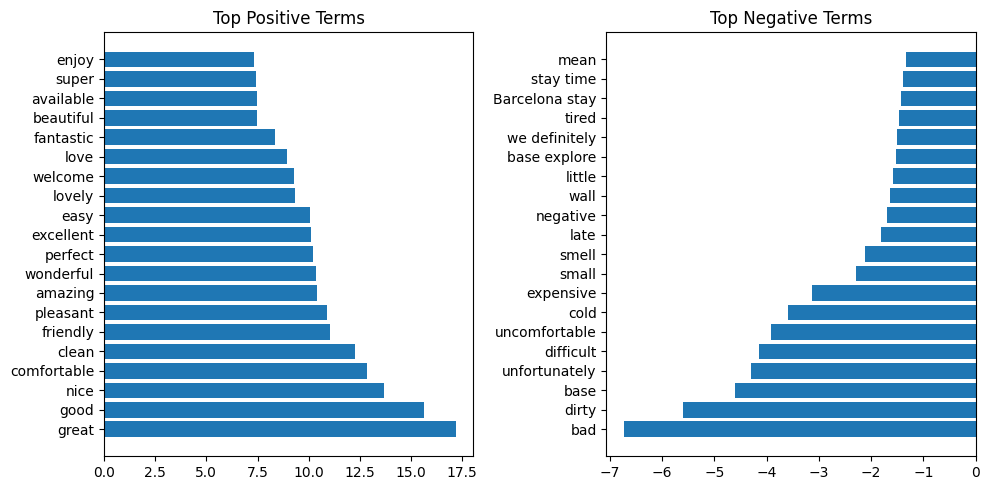

In [ ]:
# Plot to show the most important coefficients
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.barh(top_positive["term"], top_positive["coefficient"])
plt.title("Top Positive Terms")

plt.subplot(1,2,2)
plt.barh(top_negative["term"], top_negative["coefficient"])
plt.title("Top Negative Terms")

plt.tight_layout()
plt.show()

In [ ]:
# We determine importance for each topic
log_dict = dict(zip(feature_names, log_coefs))

log_topic_scores = {}

# We compute a weighted average 
for topic_id in range(lda_model.num_topics):
    words = lda_model.show_topic(topic_id, topn=15)
    
    weighted_sum = 0
    weight_total = 0
    
    for word, weight in words:
        if word in log_dict:
            weighted_sum += log_dict[word] * weight
            weight_total += weight
    
    log_topic_scores[topic_id] = weighted_sum / weight_total if weight_total > 0 else 0

log_topic_scores

{0: np.float64(2.7588589306411033),
 1: np.float64(4.305317577036128),
 2: np.float64(2.7895355794292795),
 3: np.float64(3.08488832816945)}

## 6.3 Random Forest model

In [ ]:
# We train the model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC Random Forest:", roc_auc_rf)


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      2740
           1       0.97      0.99      0.98     17295

    accuracy                           0.97     20035
   macro avg       0.96      0.91      0.93     20035
weighted avg       0.97      0.97      0.97     20035

Confusion Matrix
[[ 2291   449]
 [  142 17153]]
ROC-AUC Random Forest: 0.9877080946140714


In [ ]:
rf_importances = rf_model.feature_importances_

rf_df = pd.DataFrame({
    "term": feature_names,
    "importance": rf_importances
})

top_rf = rf_df.sort_values("importance", ascending=False).head(20)

print("Top Random Forest terms")
print(top_rf)

Top Random Forest terms
                term  importance
821            great    0.073139
796             good    0.047604
1050        location    0.043994
235        apartment    0.040645
1203            nice    0.039094
1556            stay    0.035719
443            clean    0.032961
1279         perfect    0.028749
1301           place    0.025467
910             host    0.019698
492      comfortable    0.019472
683        excellent    0.017671
767         friendly    0.014277
631             easy    0.013810
1398       recommend    0.013685
352        beautiful    0.012770
43         Barcelona    0.011385
1797         welcome    0.010917
831   great location    0.009450
222          amazing    0.008787


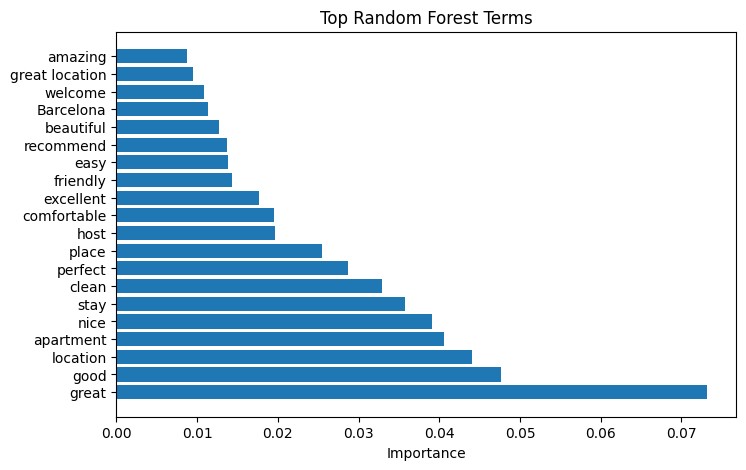

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(top_rf["term"], top_rf["importance"])

plt.title("Top Random Forest Terms")
plt.xlabel("Importance")

plt.show()

In [ ]:
# Most important topics
rf_dict = dict(zip(feature_names, rf_importances))

rf_topic_scores = {}

for topic_id in range(lda_model.num_topics):
    words = lda_model.show_topic(topic_id, topn=15)
    
    weighted_sum = 0
    weight_total = 0
    
    for word, weight in words:
        if word in rf_dict:
            weighted_sum += rf_dict[word] * weight
            weight_total += weight
    
    rf_topic_scores[topic_id] = weighted_sum / weight_total if weight_total > 0 else 0

rf_topic_scores

{0: np.float64(0.007152459205673485),
 1: np.float64(0.014415143833497028),
 2: np.float64(0.007205850091675849),
 3: np.float64(0.009500059600917429)}

## 6.4 Comparing both models

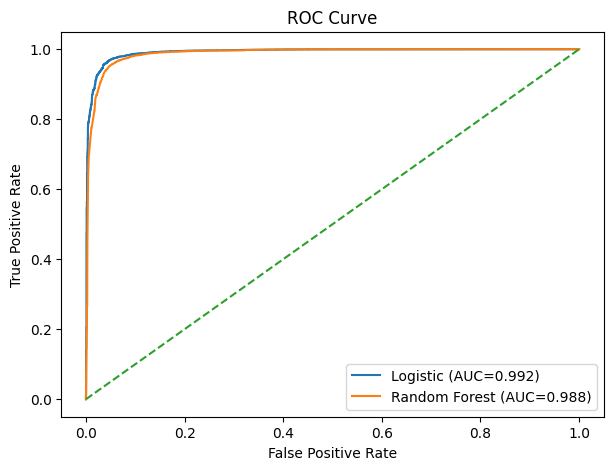

In [ ]:
# Comparison in terms of how well do they predict
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={roc_auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [ ]:
# Comparison table in terms of topic importance: We can see that they have similar conclusions, 
# where most important topic is 1, then 3, it's between 2 and 0 depending on the model.

log_df = pd.DataFrame(
    list(log_topic_scores.items()),
    columns=["Topic", "Logistic"]
)

rf_df = pd.DataFrame(
    list(rf_topic_scores.items()),
    columns=["Topic", "RandomForest"]
)

comparison_df = log_df.merge(rf_df, on="Topic")
comparison_df


,Topic,Logistic,RandomForest
0,0,2.758859,0.007152
1,1,4.305318,0.014415
2,2,2.789536,0.007206
3,3,3.084888,0.009500


In [ ]:
# Normalized average importance, to combine them into one robust measure
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

comparison_df["Log_norm"] = scaler.fit_transform(
    comparison_df[["Logistic"]]
)

comparison_df["RF_norm"] = scaler.fit_transform(
    comparison_df[["RandomForest"]]
)

comparison_df["Average"] = (
    comparison_df["Log_norm"] + comparison_df["RF_norm"]
) / 2

comparison_df.sort_values("Average", ascending=False)


,Topic,Logistic,RandomForest,Log_norm,RF_norm,Average
1,1,4.305318,0.014415,1.000000,1.000000,1.000000
3,3,3.084888,0.009500,0.210823,0.323241,0.267032
2,2,2.789536,0.007206,0.019837,0.007351,0.013594
0,0,2.758859,0.007152,0.000000,0.000000,0.000000


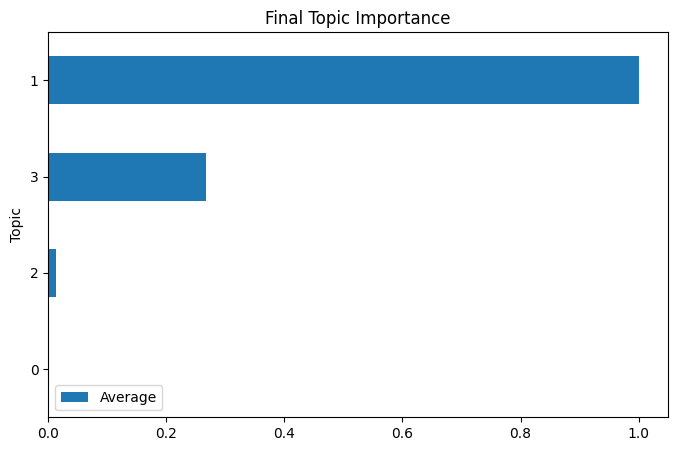

In [ ]:
# Final plot that shows the importance of each topic by taking the average of the previous normalized values. Here
# we can clearly see that topic 1 and 3 are the most important ones.
comparison_df.sort_values("Average").plot(
    x="Topic",
    y="Average",
    kind="barh",
    figsize=(8,5)
)

plt.title("Final Topic Importance")
plt.show()
